<a href="https://colab.research.google.com/github/KhusbuBubna123/Repository2/blob/main/Naive_Bayes_Fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naive Bayes

##### Bayes's Theorem

According to Wikipedia, **Bayes's theorem** describes the probability of an event,
based on prior knowledge of conditions that might be related to the event.
Mathematically:

$$P(A|B) = \\frac{P(B|A)\\cdot P(A)}{P(B)}$$

- P(A|B) — likelihood of A given B is true  
- P(B|A) — likelihood of B given A is true  
- P(A), P(B) — marginal probabilities  


**Example — rain / cloud:**

$$P(Rain|Cloud) = \\frac{P(Rain) \\times P(Cloud|Rain)}{P(Cloud)} = \\frac{0.1 \\times 0.5}{0.4} = 0.125$$

12.5% chance of rain — not too bad, let's have a picnic!


**Naïve Bayes:** assumes features are conditionally independent given the class.
Despite this (often wrong) assumption it works very well for text classification.


# Problem statement

Spam filtering using Naive Bayes classifiers — predict whether a message
is **spam** or **ham** (not spam) based on its content.


### Data processing using panda library

In [ ]:
# Import the required libraries
import string
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print('Imports OK')

Imports OK


### Loading the dataset

**FIX 1 & 2:** The original notebook had the `read_csv` line commented out
(causing `NameError: name 'data' is not defined`) and used the wrong filename.
Corrected path: `attached_assets/spam_1784565683255.tsv`


In [ ]:
data = pd.read_csv("spam.tsv",sep='\t',names=['Class','Message'])
data.head(8) # View the first 8 records of our dataset

,Class,Message
0,ham,I've been searching for the right words to tha...
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...
2,ham,"Nah I don't think he goes to usf, he lives aro..."
3,ham,Even my brother is not like to speak with me. ...
4,ham,I HAVE A DATE ON SUNDAY WITH WILL!!!
5,ham,As per your request 'Melle Melle (Oru Minnamin...
6,spam,WINNER!! As a valued network customer you have...
7,spam,Had your mobile 11 months or more? U R entitle...


In [ ]:
data.shape

(5567, 2)

### Exploratory Data Analysis

In [ ]:
data['Class'].value_counts()

Class
ham     4821
spam     746
Name: count, dtype: int64

In [ ]:
# Message length feature
data['Length'] = data['Message'].apply(len)
data.head()

,Class,Message,Length
0,ham,I've been searching for the right words to tha...,196
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
2,ham,"Nah I don't think he goes to usf, he lives aro...",61
3,ham,Even my brother is not like to speak with me. ...,77
4,ham,I HAVE A DATE ON SUNDAY WITH WILL!!!,36


In [ ]:
data['Length'].describe()

count    5567.000000
mean       80.450153
std        59.891023
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: Length, dtype: float64

In [ ]:
# Longest message
data.loc[data['Length'] == data['Length'].max(), 'Message'].values[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

In [ ]:
# Shortest message
data.loc[data['Length'] == data['Length'].min(), 'Message'].values[0]

'Ok'

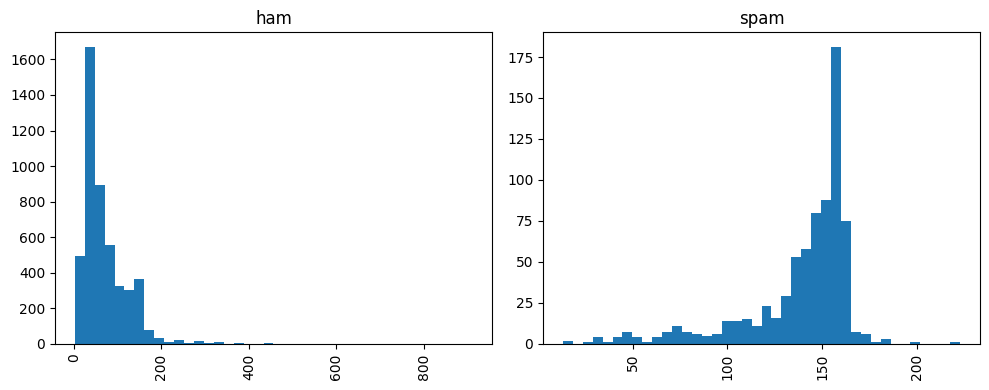

In [ ]:
# Distribution of message lengths by class
data.hist(column='Length', by='Class', bins=40, figsize=(10, 4))
plt.tight_layout()
plt.show()

### Label Encoding

**FIX 5 (SettingWithCopyWarning):** replaced chained assignment
`data['col'][row] = val` with `data.loc[row, 'col'] = val`
and map-based encoding instead of boolean indexing.


In [ ]:
# FIX 5: use .map() — no chained assignment, no SettingWithCopyWarning
# spam → 0 , ham → 1
data['Target'] = data['Class'].map({'spam': 0, 'ham': 1})
data[['Class', 'Target']].head(8)

,Class,Target
0,ham,1
1,spam,0
2,ham,1
3,ham,1
4,ham,1
5,ham,1
6,spam,0
7,spam,0


### Text Pre-processing

In [ ]:
def remove_punct(text):
    """Remove punctuation and convert to lower case."""
    return ''.join(ch for ch in text if ch not in string.punctuation).lower()

data['text_clean'] = data['Message'].apply(remove_punct)
data[['Message', 'text_clean']].head(3)

,Message,text_clean
0,I've been searching for the right words to tha...,ive been searching for the right words to than...
1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
2,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [ ]:
data.head()

,Class,Message,Length,Target,text_clean
0,ham,I've been searching for the right words to tha...,196,1,ive been searching for the right words to than...
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,0,free entry in 2 a wkly comp to win fa cup fina...
2,ham,"Nah I don't think he goes to usf, he lives aro...",61,1,nah i dont think he goes to usf he lives aroun...
3,ham,Even my brother is not like to speak with me. ...,77,1,even my brother is not like to speak with me t...
4,ham,I HAVE A DATE ON SUNDAY WITH WILL!!!,36,1,i have a date on sunday with will


### Splitting Train and Test Data

**FIX 3 (data leakage / feature-mismatch ValueError):**
The original notebook called `CV.fit_transform()` on the full dataset,
then re-fitted on the training split — creating two vectorisers with
different vocabulary sizes (9 270 vs 8 159 features), causing:
```
ValueError: X has 9270 features, but MultinomialNB is expecting 8159.
```
**Correct pipeline:** split the *raw text* first, then fit the vectoriser
on training text only, and `transform`-only the test text.


In [ ]:
# Split raw text arrays first — no vectorising yet
X_text = data['text_clean'].values
y      = data['Target'].values.astype(int)

X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=10
)

print('Train size:', len(X_text_train))
print('Test  size:', len(X_text_test))

Train size: 4453
Test  size: 1114


### Vectorisation — Bag of Words (CountVectorizer)

In [ ]:
# FIX 3 cont.: fit CV on TRAINING text only
#Count Vectorize and remove stopwords.
CV = CountVectorizer(stop_words='english')
X_train_cv = CV.fit_transform(X_text_train)  # fit + transform
X_test_cv  = CV.transform(X_text_test)        # transform only — same vocabulary

print('Vocabulary size:', len(CV.vocabulary_))
print('Train shape    :', X_train_cv.shape)
print('Test  shape    :', X_test_cv.shape)

Vocabulary size: 8159
Train shape    : (4453, 8159)
Test  shape    : (1114, 8159)


In [ ]:
# FIX 4: get_feature_names() was removed in sklearn ≥ 1.0
# Use get_feature_names_out() instead
feature_names = CV.get_feature_names_out()
print('Total features:', len(feature_names))
print('Sample words  :', feature_names[:15])

Total features: 8159
Sample words  : ['008704050406' '0089my' '0121' '01223585334' '0125698789' '02' '020603'
 '0207' '02070836089' '02072069400' '02073162414' '02085076972' '020903'
 '021' '050703']


### Training a model — MultinomialNB

With messages represented as count vectors we can train the
**Multinomial Naive Bayes** classifier, a popular choice for text.


In [ ]:
NB = MultinomialNB()
NB.fit(X_train_cv, y_train)
#alpha is used for Laplace smooothing.

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [ ]:
# Predict on test set (same CV vocabulary — no feature mismatch)
y_pred = NB.predict(X_test_cv)
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(1114,))

In [ ]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f'MultinomialNB Accuracy: {accuracy:.2f}%')

MultinomialNB Accuracy: 98.29%


In [ ]:
print(classification_report(y_test, y_pred, target_names=['spam', 'ham']))

              precision    recall  f1-score   support

        spam       0.96      0.92      0.94       168
         ham       0.99      0.99      0.99       946

    accuracy                           0.98      1114
   macro avg       0.97      0.96      0.97      1114
weighted avg       0.98      0.98      0.98      1114



In [ ]:
cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=['Actual spam', 'Actual ham'],
    columns=['Predicted spam', 'Predicted ham'],
)
cm

,Predicted spam,Predicted ham
Actual spam,155,13
Actual ham,6,940


### SpamClassificationApplication

In [ ]:
def classify_message(msg):
    """Return 'SPAM' or 'HAM (inbox)' for any message string."""
    cleaned  = remove_punct(msg)
    features = CV.transform([cleaned])
    pred     = NB.predict(features)[0]
    return 'HAM (inbox)' if pred == 1 else 'SPAM'

# Demo on four sample messages
samples = [
    'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005',
    'Hey, are we still meeting for lunch tomorrow?',
    'WINNER!! You have been selected to receive a £900 prize reward! Call now',
    "I'll be home late tonight, don't wait up",
]
for m in samples:
    print(f'  [{classify_message(m):>11}]  {m[:65]}')

  [       SPAM]  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 200
  [HAM (inbox)]  Hey, are we still meeting for lunch tomorrow?
  [       SPAM]  WINNER!! You have been selected to receive a £900 prize reward! C
  [HAM (inbox)]  I'll be home late tonight, don't wait up


## BAG OF WORDS

We cannot pass text directly to train our models in NLP — we must convert
it into numbers. The simplest approach is the **Bag of Words** model:
each document is represented as a vector of word counts.


In [ ]:
# Simple BoW example with CountVectorizer
documents = ['Dog bites man.', 'Man bites dog.', 'Dog eats meat.', 'Man eats food.']
processed = [doc.lower().replace('.', '') for doc in documents]

count_vect = CountVectorizer()
bow_rep    = count_vect.fit_transform(processed)

print('Corpus      :', processed)
print('Vocabulary  :', count_vect.vocabulary_)
print("BoW 'dog bites man'      :", bow_rep[0].toarray())
print("BoW 'man bites dog'      :", bow_rep[1].toarray())
temp = count_vect.transform(['dog and dog are friends'])
print("BoW 'dog and dog are friends':", temp.toarray())

Corpus      : ['dog bites man', 'man bites dog', 'dog eats meat', 'man eats food']
Vocabulary  : {'dog': 1, 'bites': 0, 'man': 4, 'eats': 2, 'meat': 5, 'food': 3}
BoW 'dog bites man'      : [[1 1 0 0 1 0]]
BoW 'man bites dog'      : [[1 1 0 0 1 0]]
BoW 'dog and dog are friends': [[0 2 0 0 0 0]]


## TF-IDF

In the BoW approach all words are treated equally. **TF-IDF** weights words
by how distinctive they are:

- **TF(t)** = (occurrences of t in doc) / (total terms in doc)  
- **IDF(t)** = log(total docs / docs containing t)  
- **TF-IDF(t)** = TF(t) × IDF(t)


### TF-IDF vectorisation + BernoulliNB

**FIX (toarray AttributeError):** `TfidfVectorizer.fit_transform()` returns
a *sparse* matrix. Calling `.toarray()` on it converts it to a dense ndarray.
If the cell is run a second time *X is already dense*, so `.toarray()` raises
`AttributeError: 'numpy.ndarray' object has no attribute 'toarray'`.

**Fix:** use `hasattr(X, 'toarray')` guard, or — better — perform the
conversion inline once and never overwrite X with the sparse form.


In [ ]:
# Reuse the same train/test text split for a fair comparison
tf = TfidfVectorizer()

# fit on training text only, then transform both splits
X_train_tf = tf.fit_transform(X_text_train).toarray()  # dense, once
X_test_tf  = tf.transform(X_text_test).toarray()       # dense, once

# FIX 4: get_feature_names_out() replaces deprecated get_feature_names()
print('TF-IDF features:', len(tf.get_feature_names_out()))
print('Train shape     :', X_train_tf.shape)
print('Test  shape     :', X_test_tf.shape)

TF-IDF features: 8420
Train shape     : (4453, 8420)
Test  shape     : (1114, 8420)


 8420
Train shape     : (4453, 8420)
Test  shape     : (1114, 8420)


In [ ]:
## Creating training and testing split (already done above — reuse)
# X_train_tf, X_test_tf, y_train, y_test are ready
print('Shapes OK — no extra split needed')

Shapes OK — no extra split needed


In [ ]:
## Model creation — BernoulliNB
nb = BernoulliNB(alpha=0.01)
nb.fit(X_train_tf, y_train)
y_hat = nb.predict(X_test_tf)
y_hat

array([1, 1, 1, ..., 1, 1, 1], shape=(1114,))

In [ ]:
print(classification_report(y_test, y_hat, target_names=['spam', 'ham']))

              precision    recall  f1-score   support

        spam       0.99      0.92      0.96       168
         ham       0.99      1.00      0.99       946

    accuracy                           0.99      1114
   macro avg       0.99      0.96      0.97      1114
weighted avg       0.99      0.99      0.99      1114



In [ ]:
## Confusion matrix
pd.crosstab(y_test, y_hat, rownames=['Actual'], colnames=['Predicted'])

Predicted,0,1
Actual,,
0,155,13
1,1,945


In [ ]:
## Accuracy
print(f'BernoulliNB Accuracy: {accuracy_score(y_test, y_hat)*100:.2f}%')

BernoulliNB Accuracy: 98.74%


## Summary — Model Comparison

In [ ]:
acc_mnb = accuracy_score(y_test, y_pred)  * 100
acc_bnb = accuracy_score(y_test, y_hat)   * 100
print(f'CountVectorizer + MultinomialNB : {acc_mnb:.2f}%')
print(f'TF-IDF          + BernoulliNB   : {acc_bnb:.2f}%')

CountVectorizer + MultinomialNB : 98.29%
TF-IDF          + BernoulliNB   : 98.74%


### Pros of Naive Bayes

- Fast and highly scalable
- Works for binary and multi-class classification
- Simple — depends on counting
- Great for text / spam filtering
- Trains well on small datasets
- Handles missing data gracefully


### Cons of Naive Bayes

- Assumes all features are independent — cannot learn feature relationships
- Can learn individual feature importance but not inter-feature correlations


## Application of Naive Bayes

**Text classification / spam filtering / sentiment analysis:**
- News article classification (Sports, Technology …)
- Spam vs Ham — most popular method for mail filtering
- Sentiment analysis (positive / negative opinion mining)

**Recommendation systems:**
- Combined with collaborative filtering to predict user preferences


### 3 Types of Naive Bayes in scikit-learn

| Variant | Best for |
|---|---|
| **GaussianNB** | Continuous features following a normal distribution |
| **MultinomialNB** | Discrete counts (e.g. word frequencies) |
| **BernoulliNB** | Binary features (word present / absent) |
